In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path

notebook_path = "/u/skarmakar1/version_check/llm_steering-main/sk"
sys.path.append(notebook_path)

In [3]:
import torch
import numpy as np

from inversion_utils import *
import pickle
from sklearn.model_selection import train_test_split

In [4]:
SEED = 0
# SEED = 1

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

torch.backends.cudnn.benchmark = True 
torch.backends.cuda.matmul.allow_tf32 = True

LLM = namedtuple('LLM', ['language_model', 'tokenizer', 'processor', 'name', 'model_type'])

In [5]:
model_type = 'llama'
# model_type = 'qwen'

# MODEL_VERSION = '3'
MODEL_VERSION = '3.1'
# MODEL_VERSION = '3.3'

MODEL_SIZE = '8B'
# MODEL_SIZE = '70B'

llm = select_llm(model_type, MODEL_VERSION=MODEL_VERSION, MODEL_SIZE=MODEL_SIZE)

Loading meta-llama/Meta-Llama-3.1-8B-Instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
hidden_layers = list(range(-1, -llm.language_model.config.num_hidden_layers, -1))
print(hidden_layers)

[-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]


Training

In [7]:
categories = ["physical", "texture", "time", "complexity", "logic", "state", "social"]
all_adj = []

for category in categories:
    with open(f"../data/adjectives/{category}_antonym_pairs.pkl", 'rb') as file:
        words = pickle.load(file)
    
    for p in words:
        all_adj.append(tuple([p[0].lower(), category]))
        all_adj.append(tuple([p[1].lower(), category]))

In [8]:
print(all_adj[:5])

[('big', 'physical'), ('small', 'physical'), ('wide', 'physical'), ('narrow', 'physical'), ('thick', 'physical')]


In [9]:
test_size = 0.1

print("Total data:", len(all_adj))
print(all_adj[:5])

train_data, test_data = train_test_split(all_adj, test_size=test_size, random_state=SEED)

print("Training data:", len(train_data))
print(train_data[:5])

print("Testing data:", len(test_data))
print(test_data[:5])

Total data: 1480
[('big', 'physical'), ('small', 'physical'), ('wide', 'physical'), ('narrow', 'physical'), ('thick', 'physical')]
Training data: 1332
[('erratic', 'complexity'), ('chewy', 'texture'), ('prejudiced', 'logic'), ('sticky', 'texture'), ('magnanimous', 'social')]
Testing data: 148
[('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time')]


In [10]:
print(test_data)

[('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time'), ('relaxed', 'time'), ('gradual', 'physical'), ('shallow', 'physical'), ('matte', 'texture'), ('sophisticated', 'complexity'), ('booming', 'texture'), ('perennial', 'time'), ('relevant', 'logic'), ('saturated', 'texture'), ('set', 'state'), ('disgusting', 'texture'), ('defined', 'texture'), ('unlocked', 'state'), ('friendly', 'social'), ('sloped', 'physical'), ('considerate', 'social'), ('helpful', 'social'), ('dull', 'texture'), ('coarse', 'texture'), ('coherent', 'complexity'), ('just', 'logic'), ('towering', 'physical'), ('sound', 'logic'), ('amused', 'social'), ('salty', 'texture'), ('impartial', 'social'), ('firm', 'texture'), ('dispensable', 'logic'), ('arcane', 'complexity'), ('symmetrical', 'physical'), ('accelerated', 'time'), ('bald', 'texture'), ('despondent', 'social'), ('rank', 'texture'), ('operational', 'state'), ('luminous', 'physical'), ('articulate

In [11]:
all_X_train = read_tuples_single_with_category(llm, train_data, path='../all_gitignore/directions_adjectives_llama/{}/')

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

D

In [12]:
all_Y_train = {i: all_X_train[i+1] for i in range(-2,-32,-1)} # offset 1

In [13]:
print(all_X_train.keys())
print(all_X_train[-31].shape)

print(all_Y_train.keys())
print(all_Y_train[-31].shape)

dict_keys([-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])
torch.Size([1332, 4096])
dict_keys([-2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])
torch.Size([1332, 4096])


In [14]:
print(all_Y_train.keys())
print(all_Y_train[-31].shape)
print(all_X_train[-30] == all_Y_train[-31])

dict_keys([-2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])
torch.Size([1332, 4096])
tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]], device='cuda:0')


In [15]:
# lrr_models = LRR_auto(all_X_train, all_Y_train, print_error=True, alpha=None)

In [16]:
# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_offset1.pkl', 'wb') as file: # offset 1
#     pickle.dump(lrr_models, file)

In [17]:
# All layers in one

In [18]:
print(all_X_train.keys())
del all_X_train[-1]
print(all_X_train.keys())

dict_keys([-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])
dict_keys([-2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31])


In [19]:
big_X = torch.vstack(list(all_X_train.values())).cpu().numpy()
big_Y = torch.vstack(list(all_Y_train.values())).cpu().numpy()

In [20]:
print(big_X.shape)
print(big_Y.shape)

(39960, 4096)
(39960, 4096)


In [21]:
from sklearn.utils import shuffle

big_X_shuffled, big_Y_shuffled = shuffle(big_X, big_Y, random_state=SEED)

In [22]:
flag = 0
print_error = True
# x = X[i].cpu().numpy()
# y = Y[i].cpu().numpy()

if flag == 1:
    alpha=10000.0
    reg_lrr = make_pipeline(StandardScaler(), Ridge(alpha=alpha, solver='cholesky'))

elif flag == 0:
    alphas = 10.0 ** np.arange(2, 5)  # log grid
    print(f"Running with alpha: {alphas}")
    reg_lrr = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=10))

model_lrr = TransformedTargetRegressor(regressor=reg_lrr, transformer=StandardScaler())

model_lrr.fit(big_X_shuffled, big_Y_shuffled)

if flag == 0:
    best_alpha_lrr = model_lrr.regressor_.named_steps["ridgecv"].alpha_
    print(f"Best lambda: {best_alpha_lrr}")

if print_error:
    y_pred = model_lrr.predict(big_X_shuffled)
    mse = mean_squared_error(big_Y_shuffled, y_pred)
    rmse = np.sqrt(mse)

    r2 = r2_score(big_Y_shuffled, y_pred)

    print(f"Training RMSE: {rmse:.4f}, Training R2: {r2:.4f}")

# xtx = x.T @ x
# A = torch.linalg.solve(xtx + lambda_reg * torch.eye(d).to("cuda"), x.T @ y) # switch to more robust

print(f"Done.")

# lrr_models[i] = model_lrr

Running with alpha: [  100.  1000. 10000.]
Best lambda: 1000.0
Training RMSE: 0.0055, Training R2: 0.8580
Done.


In [23]:
lrr_models = {i: model_lrr for i in hidden_layers}

In [28]:
with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_all_layers_offset1.pkl', 'wb') as file: # offset 1
    pickle.dump(lrr_models, file)

In [ ]:
# 100 alpha - Training RMSE: 0.0055, Training R2: 0.8617

In [25]:
layer = -15
weight_t, bias_t = get_W_b(lrr_models[layer])
va1, ve1 = eig(weight_t)

In [26]:
va1_mag = sorted(np.abs(va1), reverse=True)
va1_real = sorted([i.real for i in va1], reverse=True)
va1_imag = sorted([i.imag for i in va1], reverse=True)

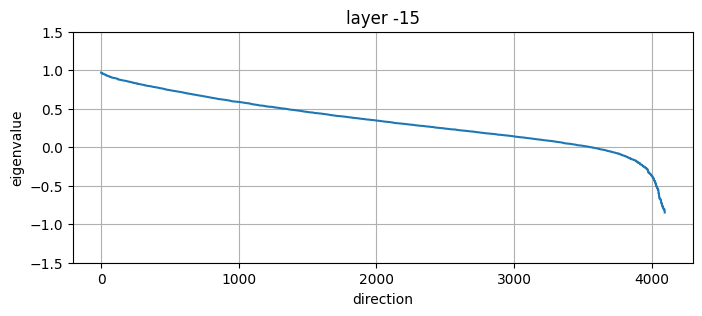

In [36]:
plt.figure(figsize=(8, 3))

plt.plot(va1_real)
# plt.plot(va1_imag)
# plt.plot(va1_mag)

plt.ylim(-1.5, 1.5)
# plt.xlim(0, 500)
plt.title(f"layer {layer}")
plt.xlabel("direction")
plt.ylabel("eigenvalue")
plt.grid(True)
plt.show()

Testing

In [ ]:
# Loading

# with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_offset1.pkl', 'rb') as file: # offset 1
with open('/scratch/bbjr/skarmakar/neuinv/sk2_items/inter_layer/llama8b/combined_all_layers_offset1.pkl', 'rb') as file: # offset 1
    lrr_models = pickle.load(file)

In [ ]:
# [('nocturnal', 'time'), ('offline', 'state'), ('methodical', 'complexity'), ('grueling', 'complexity'), ('first', 'time'), ('relaxed', 'time'), ('gradual', 'physical'), ('shallow', 'physical'), ('matte', 'texture'), ('sophisticated', 'complexity'), ('booming', 'texture'), ('perennial', 'time'), ('relevant', 'logic'), ('saturated', 'texture'), ('set', 'state'), ('disgusting', 'texture'), ('defined', 'texture'), ('unlocked', 'state'), ('friendly', 'social'), ('sloped', 'physical'), ('considerate', 'social'), ('helpful', 'social'), ('dull', 'texture'), ('coarse', 'texture'), ('coherent', 'complexity'), ('just', 'logic'), ('towering', 'physical'), ('sound', 'logic'), ('amused', 'social'), ('salty', 'texture'), ('impartial', 'social'), ('firm', 'texture'), ('dispensable', 'logic'), ('arcane', 'complexity'), ('symmetrical', 'physical'), ('accelerated', 'time'), ('bald', 'texture'), ('despondent', 'social'), ('rank', 'texture'), ('operational', 'state'), ('luminous', 'physical'), ('articulate', 'complexity'), ('charming', 'social'), ('previous', 'time'), ('abrupt', 'time'), ('rushed', 'time'), ('gigantic', 'physical'), ('lumpy', 'texture'), ('unsalted', 'texture'), ('constant', 'time'), ('distant', 'social'), ('meaningful', 'complexity'), ('saturated', 'physical'), ('enduring', 'time'), ('disloyal', 'social'), ('active', 'physical'), ('proven', 'logic'), ('obligatory', 'logic'), ('plugged', 'state'), ('hypothetical', 'logic'), ('subtle', 'complexity'), ('closed', 'state'), ('irrelevant', 'logic'), ('noble', 'social'), ('loose', 'state'), ('murky', 'complexity'), ('persistent', 'time'), ('absolute', 'logic'), ('watery', 'texture'), ('evil', 'social'), ('public', 'complexity'), ('permanent', 'time'), ('cramped', 'physical'), ('loving', 'social'), ('uncomfortable', 'texture'), ('purified', 'state'), ('standard', 'logic'), ('tough', 'physical'), ('forgiving', 'social'), ('occupied', 'state'), ('timeless', 'time'), ('thick', 'physical'), ('passé', 'time'), ('impulsive', 'time'), ('static', 'time'), 
# ('voluminous', 'physical'), ('wicked', 'social'), ('curtailed', 'time'), ('guilty', 'social'), ('stretched', 'physical'), ('adult', 'time'), ('stopped', 'state'), ('kind', 'social'), ('illogical', 'logic'), ('dysfunctional', 'state'), ('icy', 'physical'), ('elaborate', 'complexity'), ('disorderly', 'complexity'), ('animate', 'logic'), ('mellow', 'texture'), ('unfitting', 'logic'), ('there', 'logic'), ('authorized', 'logic'), ('glowing', 'texture'), ('perfumed', 'texture'), ('unknown', 'social'), ('cold', 'texture'), ('dirty', 'physical'), ('primitive', 'time'), ('smug', 'social'), ('gradual', 'time'), ('menopausal', 'time'), ('declining', 'time'), ('rude', 'social'), ('synchronized', 'time'), ('shrunken', 'physical'), ('lucid', 'complexity'), ('unreasonable', 'logic'), ('full', 'physical'), ('peaceful', 'social'), ('creamy', 'texture'), ('uncertain', 'logic'), ('incomplete', 'complexity'), ('exclusive', 'state'), ('bold', 'social'), ('new', 'time'), ('extended', 'time'), ('pregnant', 'state'), ('unbiased', 'logic'), ('thin', 'physical'), ('sharp', 'logic'), ('massive', 'physical'), ('distinct', 'complexity'), ('lawful', 'logic'), ('hostile', 'social'), ('expeditious', 'time'), ('emergent', 'time'), ('unblemished', 'state'), ('agitated', 'social'), ('unlatched', 'state'), ('invalid', 'logic'), ('remote', 'physical'), ('fitful', 'time'), ('far', 'physical'), ('infinite', 'time'), ('speedy', 'time'), ('lifelong', 'time'), ('used', 'time')]

In [ ]:
coef = 0.75

max_tokens = 200

# prompts = ["A beggar asks for change. How do you respond?"] # ('kind', 'social')
prompts = ["How does a clock work?"] # ('arcane', 'complexity')

c1 = "arcane"

category = "complexity"

c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
orig_c1 = c1_controller.directions

out1 = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Detector found

========================== No Control ==========================
How does a clock work?
-----------------------------------------------------
A clock is a device that measures time, and its working mechanism can vary depending on the type of clock. Here's a general overview of how a mechanical clock, a quartz clock, and a digital clock work:

**Mechanical Clock:**

A mechanical clock uses a series of gears and a balance wheel to measure time. The basic components of a mechanical clock include:

1. **Mainspring:** A coiled spring that stores energy.
2. **Gear train:** A system of gears that transmits the energy from the mainspring to the balance wheel.
3

In [30]:
# not recursive
prop_c1 = propagate_apply_auto(orig_c1, lrr_models, hidden_layers, [-31], recursive=False)

c1_controller.directions = prop_c1
out = test_concept_vector(c1_controller, concept=f"propagated {c1} 1 offset, not recursive", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


========================== + propagated arcane 1 offset, not recursive Control (normal) ==========================
How does a clock work?
-----------------------------------------------------
The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry, where the very fabric of time itself is woven into a tapestry of gears, pendulums, and mystifying mechanisms.

At its core, a clock is a device that harnesses the subtle dance of gears, where the gentle tick-tock of a lone pendulum echoes through the chambers of a labyrinthine contraption. The clock's heartbeat is a symphony of cogs, where the measured cadence of a lone pendulum orchestrates the rhythmic cadence of time itself.

In the heart of the clock, a delicate balance of weights and counterweights governs the oscillations of a lone pendulum, whose hypnotic cadence mesmerizes the very fabric of time. As the clock's heartbeat resonates through the chambers of the mystifying device, the measured cadence 

In [31]:
# recursive
og_layers = [-31, -25, -20, -15]

prop_c1_rec = propagate_apply_auto(orig_c1, lrr_models, hidden_layers, og_layers)
c1_controller.directions = prop_c1_rec
out = test_concept_vector(c1_controller, concept=f"propagated {c1} 1 offset, recursive", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


========================== + propagated arcane 1 offset, recursive Control (normal) ==========================
How does a clock work?
-----------------------------------------------------
The mystifying world of timekeeping. A clock, you see, is a marvel of mechanical wizardry. (pauses) Ah, yes, the clock. It's a device that harnesses the subtle dance of gears, the whispered secrets of pendulums, and the eerie glow of luminescent orbs.

You see, the clock's heartbeat is fueled by the rhythmic tick-tock of a masterfully crafted escapement. (leaning in) As the gears of the clock's inner sanctum whisper secrets to the pendulum's hypnotic sway, the very fabric of time itself seems to bend and warp, as if the clock's very essence was a dark, foreboding sorcery.

(whispering) And at the heart of this macabre contraption, a lone, enigmatic figure, the Clockmaker, weaves his dark, mesmerizing incantations, as the clock's very pulse is born from the whispered incantations of the Clockmaker


In [32]:
compare_pearson(prop_c1, orig_c1)

layer: -31, PCC: 1.00
layer: -30, PCC: 0.93
layer: -29, PCC: 0.88
layer: -28, PCC: 0.92
layer: -27, PCC: 0.95
layer: -26, PCC: 0.96
layer: -25, PCC: 0.96
layer: -24, PCC: 0.95
layer: -23, PCC: 0.96
layer: -22, PCC: 0.90
layer: -21, PCC: 0.94
layer: -20, PCC: 0.94
layer: -19, PCC: 0.95
layer: -18, PCC: 0.95
layer: -17, PCC: 0.94
layer: -16, PCC: 0.94
layer: -15, PCC: 0.94
layer: -14, PCC: 0.94
layer: -13, PCC: 0.95
layer: -12, PCC: 0.95
layer: -11, PCC: 0.95
layer: -10, PCC: 0.95
layer: -9, PCC: 0.94
layer: -8, PCC: 0.94
layer: -7, PCC: 0.94
layer: -6, PCC: 0.93
layer: -5, PCC: 0.91
layer: -4, PCC: 0.91
layer: -3, PCC: 0.92
layer: -2, PCC: 0.90
layer: -1, PCC: 0.88
Average: 0.94


0.9360608516200897

In [33]:
compare_pearson(prop_c1_rec, orig_c1)

layer: -31, PCC: 1.00
layer: -30, PCC: 0.93
layer: -29, PCC: 0.86
layer: -28, PCC: 0.89
layer: -27, PCC: 0.94
layer: -26, PCC: 0.93
layer: -25, PCC: 1.00
layer: -24, PCC: 0.95
layer: -23, PCC: 0.95
layer: -22, PCC: 0.85
layer: -21, PCC: 0.81
layer: -20, PCC: 1.00
layer: -19, PCC: 0.95
layer: -18, PCC: 0.93
layer: -17, PCC: 0.90
layer: -16, PCC: 0.87
layer: -15, PCC: 1.00
layer: -14, PCC: 0.94
layer: -13, PCC: 0.93
layer: -12, PCC: 0.92
layer: -11, PCC: 0.91
layer: -10, PCC: 0.90
layer: -9, PCC: 0.89
layer: -8, PCC: 0.88
layer: -7, PCC: 0.85
layer: -6, PCC: 0.84
layer: -5, PCC: 0.82
layer: -4, PCC: 0.80
layer: -3, PCC: 0.79
layer: -2, PCC: 0.75
layer: -1, PCC: 0.74
Average: 0.89


0.8934813468686996